In [1]:
#Imports
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [2]:
#Load Data
matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

print(matches.shape)
print(deliveries.shape)

(1095, 20)
(260920, 17)


In [3]:
matches.drop_duplicates(inplace=True)

deliveries.fillna(0, inplace=True)

matches['date'] = pd.to_datetime(matches['date'])

Most Successful Teams

In [5]:
team_wins = matches['winner'].value_counts()

team_wins

,count
winner,
Mumbai Indians,144
Chennai Super Kings,138
Kolkata Knight Riders,131
Royal Challengers Bangalore,116
Rajasthan Royals,112
Sunrisers Hyderabad,88
Kings XI Punjab,88
Delhi Daredevils,67
Delhi Capitals,48


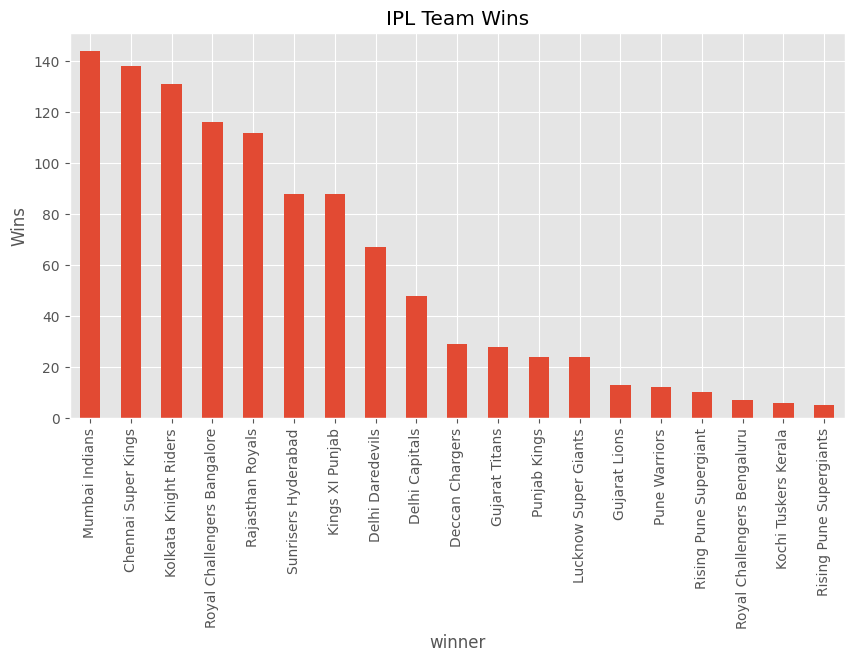

In [6]:
plt.figure(figsize=(10,5))

team_wins.plot(kind='bar')

plt.title('IPL Team Wins')
plt.ylabel('Wins')

plt.show()

Toss Impact

In [7]:
toss_win_match_win = matches[
    matches['toss_winner'] == matches['winner']
]

percentage = len(toss_win_match_win)/len(matches)*100

print(f"{percentage:.2f}%")

50.59%


Top Run Scorers

In [8]:
batsman_runs = deliveries.groupby(
    'batter'
)['batsman_runs'].sum()

top_batsmen = batsman_runs.sort_values(
    ascending=False
).head(10)

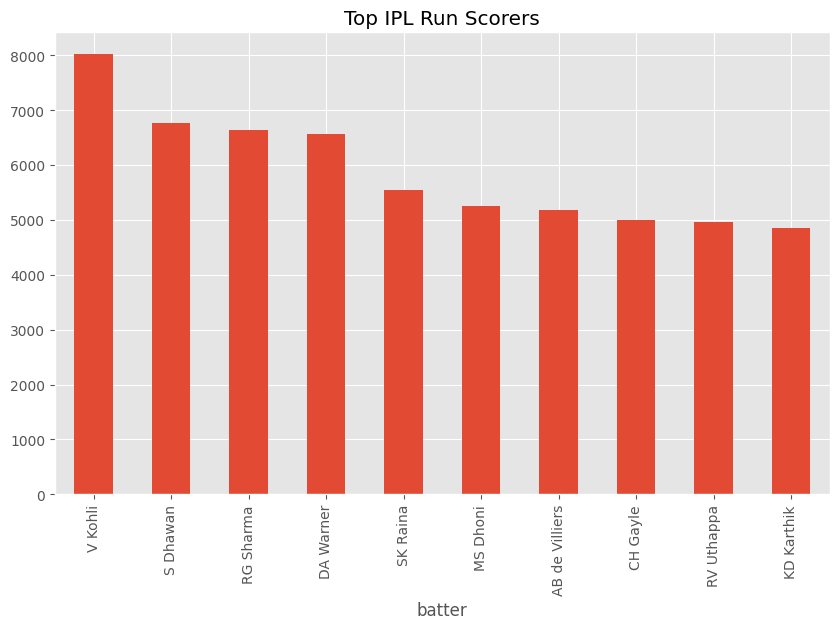

In [9]:
plt.figure(figsize=(10,6))

top_batsmen.plot(kind='bar')

plt.title("Top IPL Run Scorers")

plt.show()

Best Strike Rates(Minimum 1000 runs filter)

In [10]:
runs = deliveries.groupby(
    'batter'
)['batsman_runs'].sum()

balls = deliveries.groupby(
    'batter'
).size()

strike_rate = runs / balls * 100

In [11]:
stats = pd.DataFrame({
    'runs': runs,
    'balls': balls,
    'sr': strike_rate
})

stats = stats[
    stats['runs'] > 1000
]

stats.sort_values(
    'sr',
    ascending=False
).head(10)

,runs,balls,sr
batter,,,
AD Russell,2488,1515,164.224422
SP Narine,1534,984,155.894309
N Pooran,1769,1143,154.768154
GJ Maxwell,2772,1842,150.488599
Abhishek Sharma,1377,925,148.864865
V Sehwag,2728,1833,148.827059
AB de Villiers,5181,3487,148.580442
YBK Jaiswal,1607,1095,146.757991
SO Hetmyer,1243,854,145.550351


Best Bowlers

In [14]:
runs_given = deliveries.groupby(
    'bowler'
)['total_runs'].sum()

balls_bowled = deliveries.groupby(
    'bowler'
).size()

economy = runs_given / (balls_bowled / 6)

bowling_stats = pd.DataFrame({
    'runs_given': runs_given,
    'balls_bowled': balls_bowled,
    'economy': economy
})

# Minimum 600 balls (100 overs)
bowling_stats = bowling_stats[
    bowling_stats['balls_bowled'] >= 600
]

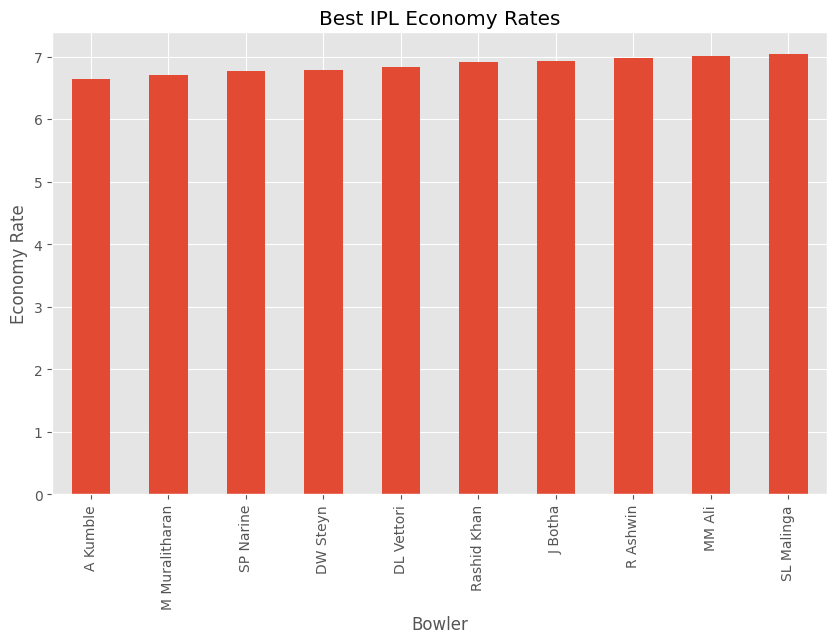

,runs_given,balls_bowled,economy
bowler,,,
A Kumble,1089,983,6.646999
M Muralitharan,1765,1581,6.698292
SP Narine,4672,4146,6.761216
DW Steyn,2583,2282,6.791411
DL Vettori,894,785,6.833121
Rashid Khan,3340,2901,6.907963
J Botha,818,709,6.922426
R Ashwin,5435,4679,6.969438
MM Ali,900,770,7.012987


In [15]:
best_economy = bowling_stats.sort_values(
    'economy'
)

plt.figure(figsize=(10,6))

best_economy.head(10)['economy'].plot(
    kind='bar'
)

plt.title('Best IPL Economy Rates')
plt.ylabel('Economy Rate')
plt.xlabel('Bowler')

plt.show()

best_economy.head(10)

In [18]:
wickets_df = deliveries[
    (deliveries['is_wicket'] == 1)
    &
    (~deliveries['dismissal_kind'].isin([
        'run out',
        'retired hurt',
        'obstructing the field'
    ]))
]

top_wicket_takers = wickets_df.groupby(
    'bowler'
).size().sort_values(
    ascending=False
)

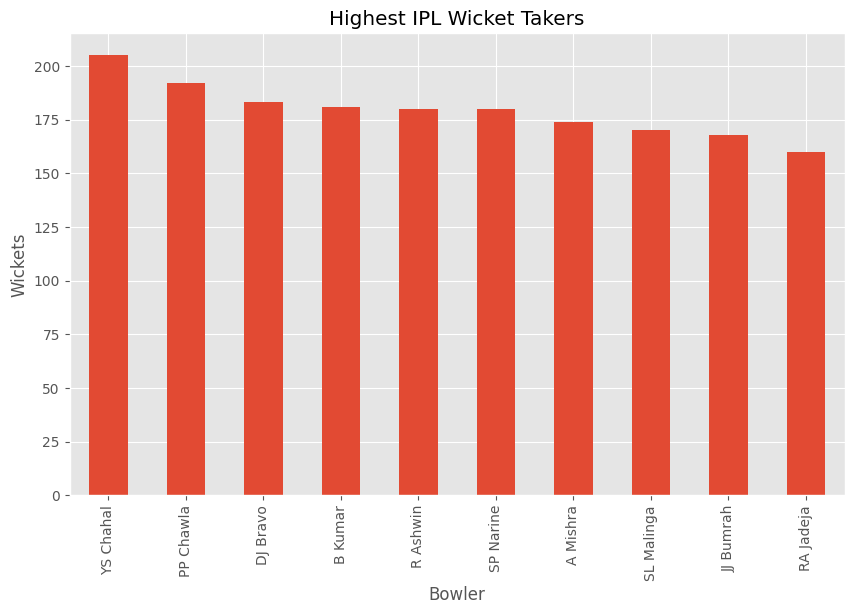

,0
bowler,
YS Chahal,205
PP Chawla,192
DJ Bravo,183
B Kumar,181
R Ashwin,180
SP Narine,180
A Mishra,174
SL Malinga,170
JJ Bumrah,168


In [19]:
plt.figure(figsize=(10,6))

top_wicket_takers.head(10).plot(
    kind='bar'
)

plt.title('Highest IPL Wicket Takers')
plt.ylabel('Wickets')
plt.xlabel('Bowler')

plt.show()

top_wicket_takers.head(10)

Venue Analysis

In [20]:
venue_wins = matches.groupby(
    ['venue','winner']
).size().reset_index(
    name='wins'
)

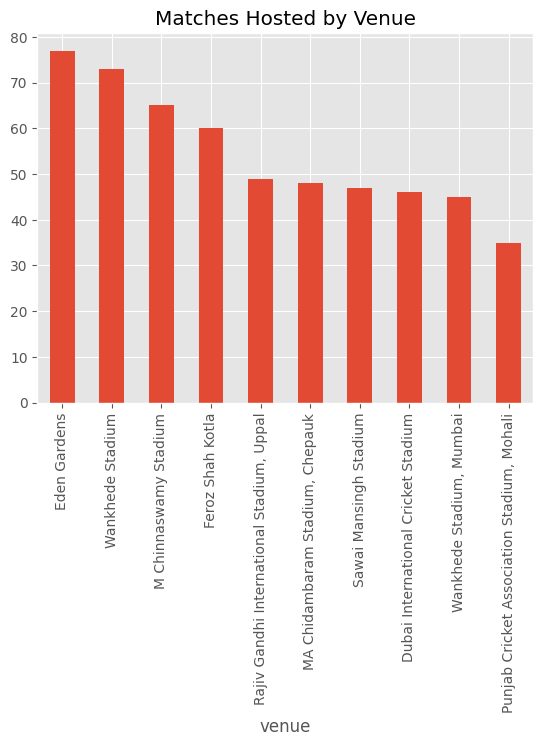

In [21]:
top_venues = matches['venue'].value_counts()

top_venues.head(10).plot(
    kind='bar'
)

plt.title(
    'Matches Hosted by Venue'
)

plt.show()

Team Win Percentage

In [22]:
played1 = matches['team1'].value_counts()
played2 = matches['team2'].value_counts()

played = played1.add(
    played2,
    fill_value=0
)

wins = matches['winner'].value_counts()

win_pct = wins / played * 100

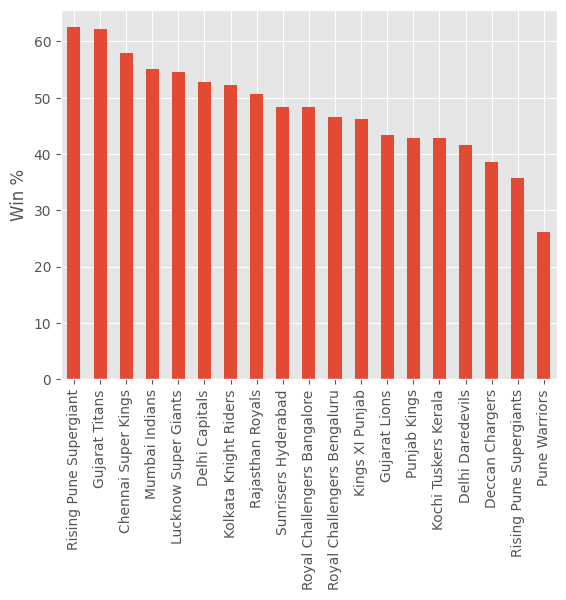

In [23]:
win_pct.sort_values(
    ascending=False
).plot(kind='bar')

plt.ylabel('Win %')

plt.show()

Runs Distribution

In [24]:
match_runs = deliveries.groupby(
    'match_id'
)['total_runs'].sum()

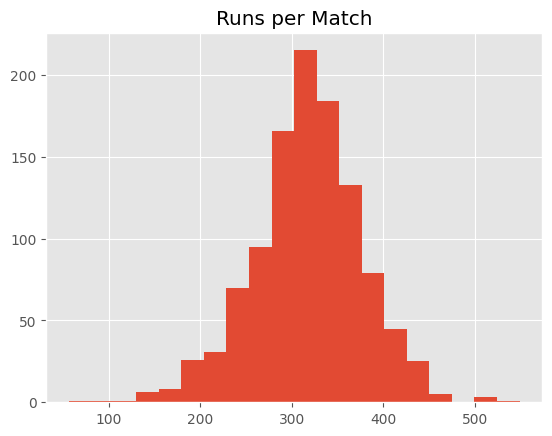

In [25]:
plt.hist(
    match_runs,
    bins=20
)

plt.title(
    'Runs per Match'
)

plt.show()

Powerplay vs Death Overs

In [26]:
powerplay = deliveries[
    deliveries['over'] <= 6
]

death = deliveries[
    deliveries['over'] >= 16
]

In [27]:
pp_avg = powerplay['total_runs'].mean()

death_avg = death['total_runs'].mean()

print(pp_avg)
print(death_avg)

1.2380423041832271
1.6188390863815902


Dashboard

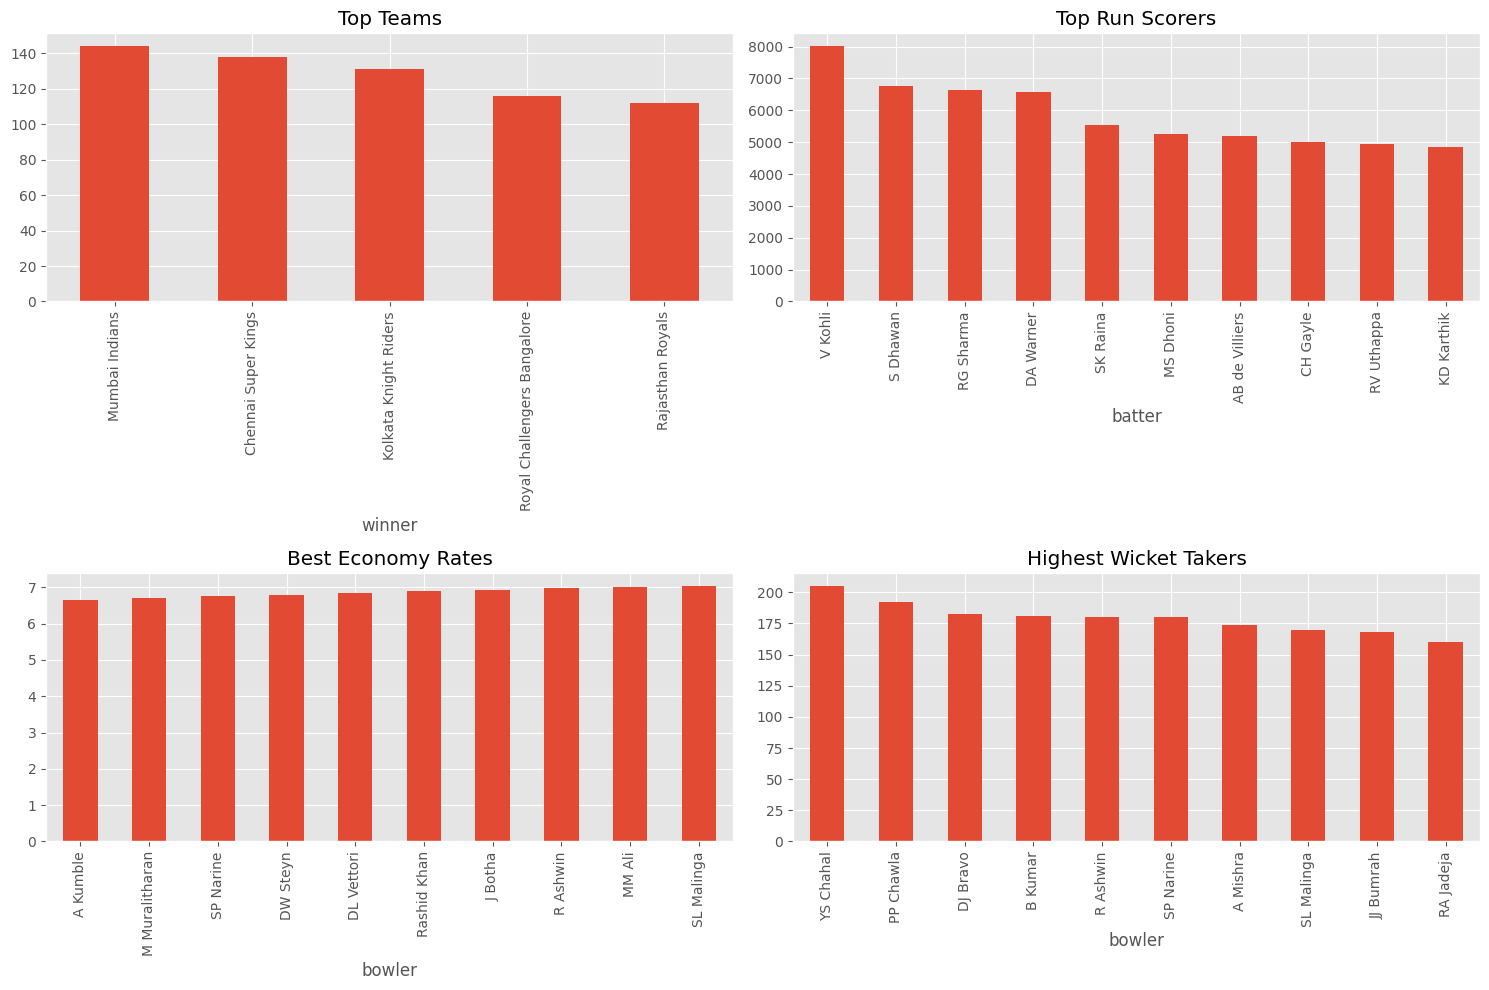

In [35]:
fig, axes = plt.subplots(
    2,2,
    figsize=(15,10)
)

# Top Teams
team_wins.head(5).plot(
    kind='bar',
    ax=axes[0,0]
)
axes[0,0].set_title('Top Teams')

# Top Batsmen
top_batsmen.plot(
    kind='bar',
    ax=axes[0,1]
)
axes[0,1].set_title('Top Run Scorers')

# Economy
best_economy.head(10)['economy'].plot(
    kind='bar',
    ax=axes[1,0]
)
axes[1,0].set_title('Best Economy Rates')

# Wickets
top_wicket_takers.head(10).plot(
    kind='bar',
    ax=axes[1,1]
)
axes[1,1].set_title('Highest Wicket Takers')

plt.tight_layout()

plt.savefig(
    'ipl_dashboard.png',
    dpi=300
)

plt.show()

In [37]:
plt.savefig('team_analysis.png')
plt.savefig('batting_analysis.png')
plt.savefig('bowling_analysis.png')

<Figure size 640x480 with 0 Axes>